# Market Basket Analysis — Online Retail Dataset

**Course:** SCS3307 Data Warehousing and Mining  
**Index Number:** 23001879

---
## 1. Import Required Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import time

# Association rule mining
from mlxtend.frequent_patterns import apriori, association_rules

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 120)

print("All libraries imported successfully.")

c:\Users\senhi\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


All libraries imported successfully.


---
## 2. Load the Dataset

In [2]:
# Load the Online Retail dataset from Excel
df = pd.read_excel('OnlineRetail.xlsx')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Basic info about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [4]:
# Check for missing values
missing = df.isnull().sum()
missing[missing > 0]
unique_countries = df['Country'].nunique() 
print(f"Number of unique countries in the dataset: {unique_countries}")

Number of unique countries in the dataset: 38


---
## 3. Data Preprocessing

Market Basket Analysis requires clean, transactional data. The following steps prepare the raw dataset for the Apriori algorithm.

### 3.1 Remove Cancelled Transactions

Invoice numbers starting with **'C'** indicate cancelled orders. These are not actual sales and would distort the analysis, so we remove them.

In [5]:
print(f"Rows before removing cancellations: {len(df)}")

# Filter out invoices that start with 'C'
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

print(f"Rows after removing cancellations: {len(df)}")

Rows before removing cancellations: 541909
Rows after removing cancellations: 532621


### 3.2 Remove Missing Values

Rows with missing **CustomerID** cannot be attributed to a customer and are excluded.  
Rows with missing **Description** provide no product information and are also removed.

In [6]:
print(f"Rows before removing missing values: {len(df)}")

# Drop rows where CustomerID or Description is missing
df = df.dropna(subset=['CustomerID', 'Description'])

print(f"Rows after removing missing values: {len(df)}")

Rows before removing missing values: 532621
Rows after removing missing values: 397924


### 3.3 Remove Non-Positive Quantities

Transactions with `Quantity <= 0` represent returns or adjustments, not actual purchases. These are filtered out.

In [7]:
print(f"Rows before removing non-positive quantities: {len(df)}")
print(f"  Quantity <= 0 count: {(df['Quantity'] <= 0).sum()}")

df = df[df['Quantity'] > 0]

print(f"Rows after removing non-positive quantities: {len(df)}")

Rows before removing non-positive quantities: 397924
  Quantity <= 0 count: 0
Rows after removing non-positive quantities: 397924


### 3.4 Select a Single Country — United Kingdom


In [8]:
print(f"Rows before country filter: {len(df)}")
print(f"Country distribution:\n{df['Country'].value_counts().head(10)}")

df = df[df['Country'] == 'United Kingdom']

print(f"\nRows after filtering for United Kingdom: {len(df)}")

Rows before country filter: 397924
Country distribution:
Country
United Kingdom    354345
Germany             9042
France              8342
EIRE                7238
Spain               2485
Netherlands         2363
Belgium             2031
Switzerland         1842
Portugal            1462
Australia           1185
Name: count, dtype: int64

Rows after filtering for United Kingdom: 354345


### 3.5 Create a Basket Format

The Apriori algorithm requires a **binary matrix** where:
- **Rows** = individual invoices (transactions)
- **Columns** = individual products (StockCode / Description)
- **Values** = 1 if the product was bought in that transaction, 0 otherwise

We first group by `InvoiceNo` and `Description`, sum quantities, then unstack and binarise.

In [9]:
# Create a basket: group by InvoiceNo and Description, sum Quantity
basket = df.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0)

print(f"Basket shape: {basket.shape}")
basket.head()

Basket shape: (16649, 3844)


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,TOADSTOOL BEDSIDE LIGHT,TRELLIS COAT RACK,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,12 PENCILS TALL TUBE POSY,12 PENCILS TALL TUBE RED RETROSPOT,12 PENCILS TALL TUBE SKULLS,12 PENCILS TALL TUBE WOODLAND,...,ZINC HEART T-LIGHT HOLDER,ZINC STAR T-LIGHT HOLDER,ZINC BOX SIGN HOME,ZINC FINISH 15CM PLANTER POTS,ZINC FOLKART SLEIGH BELLS,ZINC HEART FLOWER T-LIGHT HOLDER,ZINC HEART LATTICE 2 WALL PLANTER,ZINC HEART LATTICE CHARGER LARGE,ZINC HEART LATTICE CHARGER SMALL,ZINC HEART LATTICE T-LIGHT HOLDER,ZINC HEART LATTICE TRAY OVAL,ZINC HEARTS PLANT POT HOLDER,ZINC HERB GARDEN CONTAINER,ZINC METAL HEART DECORATION,ZINC PLANT POT HOLDER,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
536365,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536366,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536367,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536368,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
# Convert values to binary (True/False): 1 if quantity > 0, else 0
def encode_binary(x):
    return 1 if x > 0 else 0

basket_binary = basket.map(encode_binary).astype(bool)

print(f"Binary basket shape: {basket_binary.shape}")
print(f"Non-zero entries: {basket_binary.sum().sum()}")
basket_binary.head()

Binary basket shape: (16649, 3844)
Non-zero entries: 344362


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,TOADSTOOL BEDSIDE LIGHT,TRELLIS COAT RACK,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,12 PENCILS TALL TUBE POSY,12 PENCILS TALL TUBE RED RETROSPOT,12 PENCILS TALL TUBE SKULLS,12 PENCILS TALL TUBE WOODLAND,...,ZINC HEART T-LIGHT HOLDER,ZINC STAR T-LIGHT HOLDER,ZINC BOX SIGN HOME,ZINC FINISH 15CM PLANTER POTS,ZINC FOLKART SLEIGH BELLS,ZINC HEART FLOWER T-LIGHT HOLDER,ZINC HEART LATTICE 2 WALL PLANTER,ZINC HEART LATTICE CHARGER LARGE,ZINC HEART LATTICE CHARGER SMALL,ZINC HEART LATTICE T-LIGHT HOLDER,ZINC HEART LATTICE TRAY OVAL,ZINC HEARTS PLANT POT HOLDER,ZINC HERB GARDEN CONTAINER,ZINC METAL HEART DECORATION,ZINC PLANT POT HOLDER,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
536365,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
536366,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
536367,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
536368,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
536369,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
# Check sparsity
total_cells = basket_binary.shape[0] * basket_binary.shape[1]
nonzero_cells = basket_binary.sum().sum()
sparsity = 1 - (nonzero_cells / total_cells)

print(f"Total cells: {total_cells:,}")
print(f"Non-zero cells: {nonzero_cells:,}")
print(f"Sparsity: {sparsity:.4f} ({sparsity*100:.2f}%)")

Total cells: 63,998,756
Non-zero cells: 344,362
Sparsity: 0.9946 (99.46%)


---
## 4. Market Basket Analysis — Apriori Algorithm

We experiment with **three support thresholds** to see how the number of itemsets changes.

### 4.1 Experiment 1 — Support = 0.05 (High threshold, fewer itemsets)

In [12]:
min_support_1 = 0.05

start = time.time()
frequent_itemsets_1 = apriori(basket_binary, min_support=min_support_1, use_colnames=True)
elapsed_1 = time.time() - start

print(f"Support threshold: {min_support_1}")
print(f"Number of frequent itemsets: {len(frequent_itemsets_1)}")
print(f"Time taken: {elapsed_1:.2f} seconds")
frequent_itemsets_1.head(10)

Support threshold: 0.05
Number of frequent itemsets: 19
Time taken: 0.11 seconds


,support,itemsets
0,0.078083,frozenset({ASSORTED COLOUR BIRD ORNAMENT})
1,0.055739,frozenset({HEART OF WICKER SMALL})
2,0.086912,frozenset({JUMBO BAG RED RETROSPOT})
3,0.059823,frozenset({LUNCH BAG BLACK SKULL.})
4,0.052976,frozenset({LUNCH BAG CARS BLUE})
5,0.050934,frozenset({LUNCH BAG PINK POLKADOT})
6,0.067271,frozenset({LUNCH BAG RED RETROSPOT})
7,0.052436,frozenset({LUNCH BAG SPACEBOY DESIGN })
8,0.050213,frozenset({LUNCH BAG SUKI DESIGN })
9,0.056340,frozenset({NATURAL SLATE HEART CHALKBOARD })


### 4.2 Experiment 2 — Support = 0.03 (Medium threshold)

In [13]:
min_support_2 = 0.03

start = time.time()
frequent_itemsets_2 = apriori(basket_binary, min_support=min_support_2, use_colnames=True)
elapsed_2 = time.time() - start

print(f"Support threshold: {min_support_2}")
print(f"Number of frequent itemsets: {len(frequent_itemsets_2)}")
print(f"Time taken: {elapsed_2:.2f} seconds")
frequent_itemsets_2.head(10)

Support threshold: 0.03
Number of frequent itemsets: 89
Time taken: 0.25 seconds


,support,itemsets
0,0.037720,frozenset({6 RIBBONS RUSTIC CHARM})
1,0.035257,frozenset({60 TEATIME FAIRY CAKE CASES})
2,0.041444,frozenset({ALARM CLOCK BAKELIKE GREEN})
3,0.045528,frozenset({ALARM CLOCK BAKELIKE RED })
4,0.031353,frozenset({ANTIQUE SILVER T-LIGHT GLASS})
5,0.078083,frozenset({ASSORTED COLOUR BIRD ORNAMENT})
6,0.043366,frozenset({BAKING SET 9 PIECE RETROSPOT })
7,0.030512,frozenset({CHARLOTTE BAG SUKI DESIGN})
8,0.030512,frozenset({CHILLI LIGHTS})
9,0.039822,frozenset({CHOCOLATE HOT WATER BOTTLE})


### 4.3 Experiment 3 — Support = 0.02 (Low threshold, more itemsets)

In [14]:
min_support_3 = 0.02

start = time.time()
frequent_itemsets_3 = apriori(basket_binary, min_support=min_support_3, use_colnames=True)
elapsed_3 = time.time() - start

print(f"Support threshold: {min_support_3}")
print(f"Number of frequent itemsets: {len(frequent_itemsets_3)}")
print(f"Time taken: {elapsed_3:.2f} seconds")
frequent_itemsets_3.head(10)

Support threshold: 0.02
Number of frequent itemsets: 235
Time taken: 0.95 seconds


,support,itemsets
0,0.022404,frozenset({3 STRIPEY MICE FELTCRAFT})
1,0.037720,frozenset({6 RIBBONS RUSTIC CHARM})
2,0.025767,frozenset({60 CAKE CASES VINTAGE CHRISTMAS})
3,0.035257,frozenset({60 TEATIME FAIRY CAKE CASES})
4,0.026668,frozenset({72 SWEETHEART FAIRY CAKE CASES})
5,0.041444,frozenset({ALARM CLOCK BAKELIKE GREEN})
6,0.025467,frozenset({ALARM CLOCK BAKELIKE IVORY})
7,0.029491,frozenset({ALARM CLOCK BAKELIKE PINK})
8,0.045528,frozenset({ALARM CLOCK BAKELIKE RED })
9,0.031353,frozenset({ANTIQUE SILVER T-LIGHT GLASS})


### 4.4 Comparison of Support Thresholds

In [15]:
print(f"{'Support':<20} {'Frequent Itemsets':<25} {'Time (s)':<15}")
print("-" * 60)
print(f"{min_support_1:<20} {len(frequent_itemsets_1):<25} {elapsed_1:<15.2f}")
print(f"{min_support_2:<20} {len(frequent_itemsets_2):<25} {elapsed_2:<15.2f}")
print(f"{min_support_3:<20} {len(frequent_itemsets_3):<25} {elapsed_3:<15.2f}")

Support              Frequent Itemsets         Time (s)       
------------------------------------------------------------
0.05                 19                        0.11           
0.03                 89                        0.25           
0.02                 235                       0.95           


**Observation:** As we lower the support threshold, more itemsets qualify as frequent.  
For the remainder of the analysis we use the itemsets from **Support = 0.02** to obtain a richer set of rules.

---
## 5. Generate Association Rules

Association rules are derived from frequent itemsets. We use **confidence** as the primary metric and also inspect **lift**.

In [16]:
# Generate rules from the lowest-support itemsets (richest set)
rules = association_rules(frequent_itemsets_3, metric='confidence', min_threshold=0.4)

print(f"Number of rules generated: {len(rules)}")
rules.head()

Number of rules generated: 52


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,frozenset({ALARM CLOCK BAKELIKE GREEN}),frozenset({ALARM CLOCK BAKELIKE RED }),0.041444,0.045528,0.027269,0.657971,14.451925,0.025382,2.790617,0.971049
1,frozenset({ALARM CLOCK BAKELIKE RED }),frozenset({ALARM CLOCK BAKELIKE GREEN}),0.045528,0.041444,0.027269,0.598945,14.451925,0.025382,2.390084,0.975204
2,frozenset({GARDENERS KNEELING PAD CUP OF TEA }),frozenset({GARDENERS KNEELING PAD KEEP CALM }),0.037660,0.044567,0.027509,0.730463,16.390122,0.025831,3.544712,0.975734
3,frozenset({GARDENERS KNEELING PAD KEEP CALM }),frozenset({GARDENERS KNEELING PAD CUP OF TEA }),0.044567,0.037660,0.027509,0.617251,16.390122,0.025831,2.514283,0.982788
4,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.029611,0.036759,0.024266,0.819473,22.293137,0.023177,5.335706,0.984289


In [17]:
# Sort rules by lift (descending) to find strongest associations
rules_sorted = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f"Total rules (confidence >= 0.4): {len(rules_sorted)}")
rules_sorted.head(10)

Total rules (confidence >= 0.4): 52


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.023004,0.036759,0.020482,0.890339,24.221015,0.019636,8.783841,0.981287
1,frozenset({GREEN REGENCY TEACUP AND SAUCER}),"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",0.036759,0.023004,0.020482,0.557190,24.221015,0.019636,2.206352,0.995300
2,frozenset({PINK REGENCY TEACUP AND SAUCER}),"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",0.029611,0.028590,0.020482,0.691684,24.192941,0.019635,3.150691,0.987919
3,"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",frozenset({PINK REGENCY TEACUP AND SAUCER}),0.028590,0.029611,0.020482,0.716387,24.192941,0.019635,3.421518,0.986881
4,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({PINK REGENCY TEACUP AND SAUCER}),0.036759,0.029611,0.024266,0.660131,22.293137,0.023177,2.855182,0.991593
5,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.029611,0.036759,0.024266,0.819473,22.293137,0.023177,5.335706,0.984289
6,frozenset({ROSES REGENCY TEACUP AND SAUCER }),"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",0.040723,0.024266,0.020482,0.502950,20.726763,0.019494,1.963050,0.992157
7,"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.024266,0.040723,0.020482,0.844059,20.726763,0.019494,6.151553,0.975423
8,frozenset({ROSES REGENCY TEACUP AND SAUCER }),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.040723,0.036759,0.028590,0.702065,19.099148,0.027093,3.233057,0.987871
9,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.036759,0.040723,0.028590,0.777778,19.099148,0.027093,4.316746,0.983805


---
## 6. Rule Analysis

### Top 15 Rules by Lift

In [18]:
# Display top 15 rules with relevant columns
top_rules = rules_sorted.head(15)[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

# Format for readability
top_rules['antecedents'] = top_rules['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
top_rules['consequents'] = top_rules['consequents'].apply(lambda x: ', '.join(sorted(list(x))))

top_rules

,antecedents,consequents,support,confidence,lift
0,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,0.020482,0.890339,24.221015
1,GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",0.020482,0.557190,24.221015
2,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.020482,0.691684,24.192941
3,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER,0.020482,0.716387,24.192941
4,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.024266,0.660131,22.293137
5,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.024266,0.819473,22.293137
6,ROSES REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",0.020482,0.502950,20.726763
7,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",ROSES REGENCY TEACUP AND SAUCER,0.020482,0.844059,20.726763
8,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.028590,0.702065,19.099148
9,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.028590,0.777778,19.099148


---
## 7. Visualisation

### 7.1 Top 10 Rules by Lift — Bar Chart

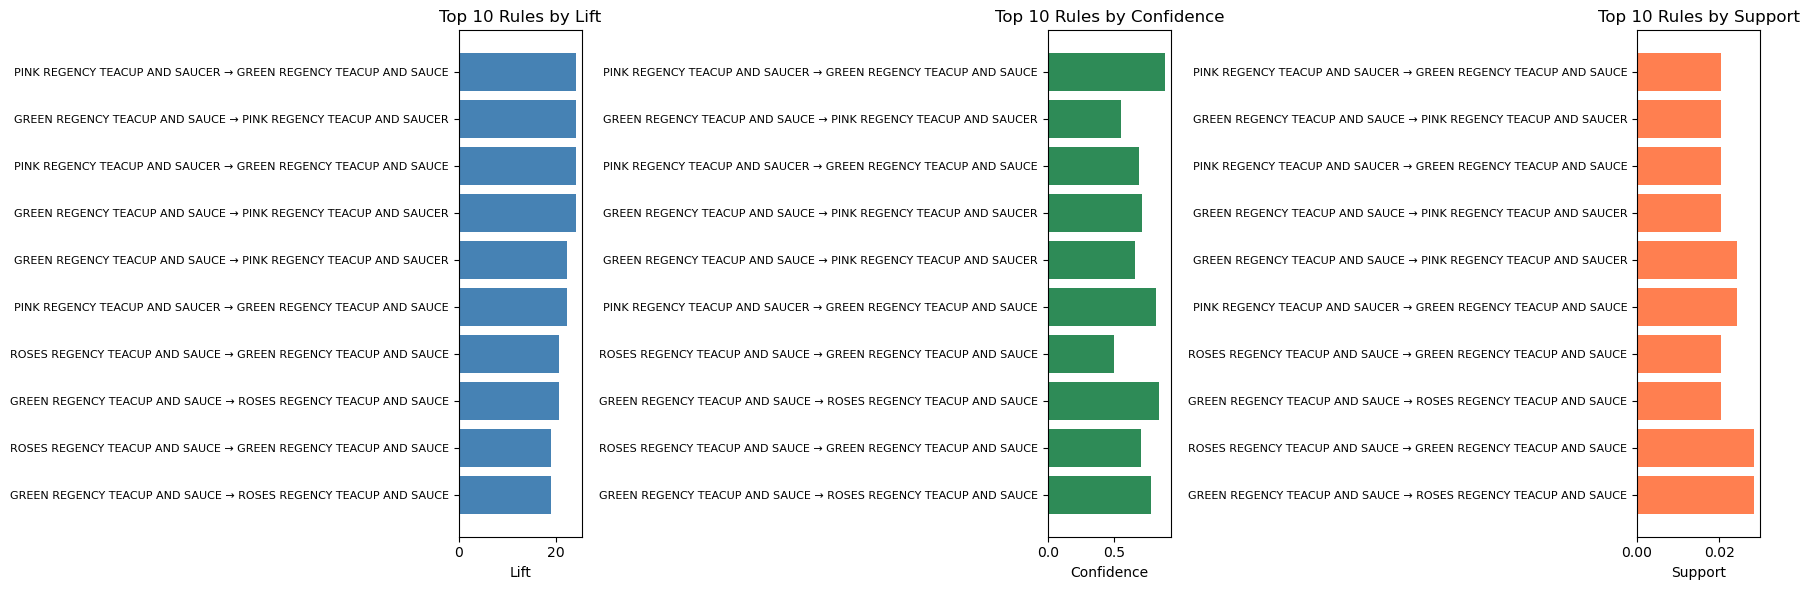

In [19]:
# Prepare top 10 rules for plotting
plot_data = rules_sorted.head(10).copy()
plot_data['rule'] = plot_data['antecedents'].apply(
    lambda x: ', '.join(sorted(list(x)))[:30]
) + ' → ' + plot_data['consequents'].apply(
    lambda x: ', '.join(sorted(list(x)))[:30]
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Bar chart for Lift
axes[0].barh(range(len(plot_data)), plot_data['lift'], color='steelblue')
axes[0].set_yticks(range(len(plot_data)))
axes[0].set_yticklabels(plot_data['rule'], fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel('Lift')
axes[0].set_title('Top 10 Rules by Lift')

# Bar chart for Confidence
axes[1].barh(range(len(plot_data)), plot_data['confidence'], color='seagreen')
axes[1].set_yticks(range(len(plot_data)))
axes[1].set_yticklabels(plot_data['rule'], fontsize=8)
axes[1].invert_yaxis()
axes[1].set_xlabel('Confidence')
axes[1].set_title('Top 10 Rules by Confidence')

# Bar chart for Support
axes[2].barh(range(len(plot_data)), plot_data['support'], color='coral')
axes[2].set_yticks(range(len(plot_data)))
axes[2].set_yticklabels(plot_data['rule'], fontsize=8)
axes[2].invert_yaxis()
axes[2].set_xlabel('Support')
axes[2].set_title('Top 10 Rules by Support')

plt.tight_layout()
plt.show()